In [1]:
import os
import pandas as pd
import swifter 
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

force_prep = False # set to True if we want to preprocess data by force

if os.path.exists('balanced_polusa3.csv') and not force_prep:
    prepped_polusa = pd.read_csv('balanced_polusa3.csv')
    
    # X_train, X_test, y_train, y_test = train_test_split(prepped_polusa['text'], prepped_polusa['label'], test_size=0.2, random_state=42)

    # First, split off the holdout set (e.g., 10–15% of data)
    X_temp, X_holdout, y_temp, y_holdout = train_test_split(
        prepped_polusa['text'], prepped_polusa['label'], test_size=0.15, random_state=42, stratify=prepped_polusa['label']
    )

    # Then split remaining data into training and validation sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )

else:
    nltk_path = os.path.join(os.path.dirname(nltk.__file__), 'nltk_data')
    nltk.data.path.append(nltk_path)
    nltk.download('stopwords')
    nltk.download('punkt')
    nltk.download('punkt_tab')
    
    # Combine all POLUSA dataset
    files = [
            # 'polusa/2017_1.csv', 'polusa/2017_2.csv', 
            # 'polusa/2018_1.csv', 'polusa/2018_2.csv',
            'polusa/2019_1.csv', 'polusa/2019_2.csv'
            ]

    polusa = [pd.read_csv(f) for f in files]
    combined_polusa = pd.concat(polusa, ignore_index=True)

    # Drop undefined labels
    combined_polusa = combined_polusa[combined_polusa['political_leaning'] != 'UNDEFINED']

    # Drop non-predictive columns
    cd_polusa = combined_polusa.drop(['id', 'url', 'date_publish', 'authors', 'domain'], axis=1)

    # Combine article into one single text
    cd_polusa['text'] = (cd_polusa['outlet'].fillna('') + ' ' + 
                        cd_polusa['headline'].fillna('') + ' ' + 
                        cd_polusa['lead'].fillna('') + ' ' + 
                        cd_polusa['body'].fillna(''))

    # Convert political leaning into numbers
    # Center = 0, Left = 1, Right = 2
    le = LabelEncoder()
    cd_polusa['label'] = le.fit_transform(cd_polusa['political_leaning'])
    
    cleaned_polusa = cd_polusa[['text','label']]
    cleaned_polusa.head()

    # X_train, X_test, y_train, y_test = train_test_split(cleaned_polusa['text'], cleaned_polusa['label'], test_size=0.2, random_state=42)

    # First, split off the holdout set (e.g., 10–15% of data)
    X_temp, X_holdout, y_temp, y_holdout = train_test_split(
        cleaned_polusa['text'], cleaned_polusa['label'], test_size=0.15, random_state=42, stratify=cleaned_polusa['label']
    )

    # Then split remaining data into training and validation sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )

    stop_words = set(stopwords.words('english'))
    def preprocess(txt):
        txt = txt.lower()
        txt = ''.join([c for c in txt if c not in string.punctuation])
        toks = word_tokenize(txt)
        toks = [word for word in toks if word not in stop_words]
        return ' '.join(toks)

    X_holdout = X_holdout.swifter.apply(preprocess)
    X_train = X_train.swifter.apply(preprocess)
    X_test = X_test.swifter.apply(preprocess)

    prepped_polusa = pd.DataFrame({'text': pd.concat([X_train, X_test, X_holdout]), 'label': pd.concat([y_train, y_test, y_holdout])})
    prepped_polusa.to_csv('prepped_polusa.csv', index=False)
    prepped_polusa.head()

X_train
X_test



97620     cbs news ahead debates new polls show biden wi...
172872    fox news kennedy says dems repeatedly trying c...
70249     los angeles times swatting suspect linked many...
148668    npr shots health news 50 massachusetts schools...
18404     huffpost virginia cop identified part white na...
                                ...                        
36812     reuters oil prices slip concerns global econom...
134416    cbs news affidavit woman car suspect fatally s...
58845     reuters pope orders inquiry bishop us church l...
170878    fox news suspect abdeslam hear verdict attempt...
137780    reuters briefkai chieh international investmen...
Name: text, Length: 35700, dtype: object

In [2]:
print(prepped_polusa.columns)
print(prepped_polusa.dtypes)

print(prepped_polusa['label'].value_counts())

Index(['text', 'label'], dtype='object')
text     object
label     int64
dtype: object
label
0    70000
1    70000
2    70000
Name: count, dtype: int64


In [3]:
from keras._tf_keras.keras.preprocessing.text import Tokenizer
from keras._tf_keras.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

# Check length distribution of tokenized sequences
# lengths = [len(seq) for seq in tokenizer.texts_to_sequences(X_train)]
# print("Percentiles of article lengths (in tokens):")
# print(np.percentile(lengths, [50, 75, 90, 95, 99]))

X_holdout = tokenizer.texts_to_sequences(X_holdout)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)


2025-10-02 18:21:24.196828: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-02 18:21:24.233542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759400484.254948   73771 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759400484.259203   73771 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759400484.277322   73771 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [4]:
max_length = 300
X_holdout = pad_sequences(X_holdout, maxlen=max_length, padding='post')
X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post')

In [5]:
# Load GloVe
embeddings_index = {}
with open('baseline.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 50000 word vectors.


In [6]:
# Load Counterfitted GloVe
counter_embeddings = {}
with open('counter-fitting/results/c_base-glove10.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        counter_embeddings[word] = coefs

print(f'Found {len(counter_embeddings)} word vectors.')

Found 50000 word vectors.


In [7]:
retro_embeddings = {}
with open('rWN+_base-glove10.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        retro_embeddings[word] = coefs

print(f'Found {len(retro_embeddings)} word vectors.')

Found 50000 word vectors.


In [ ]:
# Prepare embedding matrix
embedding_dim = 128
word_index = tokenizer.word_index
num_words = len(word_index) + 1
embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [9]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        print('Using GPU:', gpus[0])
    except RuntimeError as e:
        print(e)
else:
    print('GPU Not found')

Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [17]:
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from keras._tf_keras.keras.optimizers import Adam
from keras._tf_keras.keras.regularizers import l2
from keras_self_attention import SeqSelfAttention

# Clear previous models and free memory
import gc
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()

# GloVe-based Embedding layer
model.add(Embedding(
    input_dim=num_words,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False   # keep GloVe fixed initially
))

# First Bidirectional BiLSTM layer 
model.add(Bidirectional(LSTM(64, dropout=0.2, return_sequences=True)))

# # Second Bidirectional BiLSTM layer 
model.add(Bidirectional(LSTM(64, dropout=0.2)))

# Attention layer
# model.add(SeqSelfAttention(
#     attention_activation='tanh'
# ))  # pip install keras-self-attention
# model.add(GlobalAveragePooling1D())

# Fully connected layers
# model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Dropout(0.4))

# Template for 1-layer BiLSTM
# model.add(Bidirectional(LSTM(32, dropout=0.1)))
# model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
# model.add(Dropout(0.1))

# Output layer
model.add(Dense(3, activation='softmax'))


In [18]:
from keras._tf_keras.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',
                           patience=2,  # how many epochs with no improvement before stopping
                           restore_best_weights=True)

In [19]:
import keras._tf_keras.keras.backend as keras_backend

# Class weights for balanced_polusa3.csv
class_weights = {
    0: 1.0,
    1: 1.0,
    2: 1.0
}

gc.collect()  
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(np.array(X_train), np.array(y_train), epochs=25, batch_size=356, class_weight=class_weights, validation_data=(X_test, y_test), callbacks=[early_stop])
gc.collect()

Epoch 1/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 59s 139ms/step - accuracy: 0.7482 - loss: 0.5999 - val_accuracy: 0.8680 - val_loss: 0.3171
Epoch 2/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 56s 140ms/step - accuracy: 0.8623 - loss: 0.3340 - val_accuracy: 0.8850 - val_loss: 0.2774
Epoch 3/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 57s 143ms/step - accuracy: 0.8615 - loss: 0.3270 - val_accuracy: 0.8851 - val_loss: 0.2754
Epoch 4/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 58s 144ms/step - accuracy: 0.8686 - loss: 0.3158 - val_accuracy: 0.8934 - val_loss: 0.2612
Epoch 5/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 80s 138ms/step - accuracy: 0.8859 - loss: 0.2776 - val_accuracy: 0.9017 - val_loss: 0.2322
Epoch 6/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 60s 150ms/step - accuracy: 0.8953 - loss: 0.2535 - val_accuracy: 0.9115 - val_loss: 0.2110
Epoch 7/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 58s 145ms/step - accuracy: 0.9020 - loss: 0.2359 - val_accuracy: 0.9194 - val_loss: 0.1970
Epoch 8/25
402/402 ━━━━━━━━━━━━━━━━━━━━ 57s 143ms/step - accuracy: 0.9084 - loss: 0

14743

1116/1116 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step
===== TRAINING AND VALIDATION SCORES =====
Accuracy: 0.9368
Precision: 0.9369
Recall: 0.9368
F1 Score: 0.9368

===== HOLDOUT ACCURACY =====
985/985 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step
Accuracy: 0.9352
Precision: 0.9353
Recall: 0.9352
F1 Score: 0.9352

Confusion Matrix:
[[11247   322   331]
 [  317 11208   375]
 [  366   544 10990]]


5127

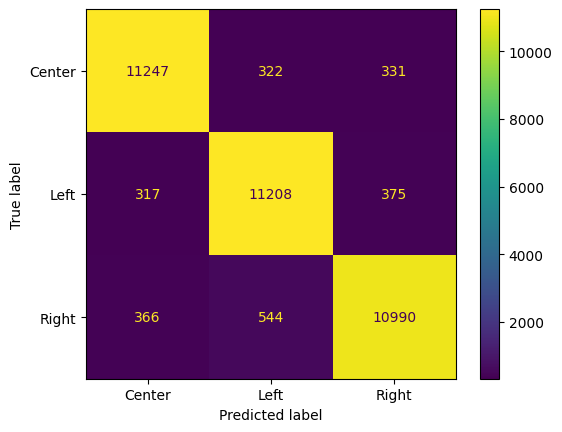

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute evaluation metrics
print("===== TRAINING AND VALIDATION SCORES =====")
print(f'Accuracy: {accuracy_score(y_test, y_pred_classes):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_classes, average='weighted'):.4f}')
print(f'Recall: {recall_score(y_test, y_pred_classes, average='weighted'):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}')

print("\n===== HOLDOUT ACCURACY =====")
# loss, accuracy = model.evaluate(X_holdout, y_holdout)
# print(f"Holdout accuracy: {accuracy:.4f}")

y_pred_holdout = model.predict(X_holdout)
y_holdout_classes = np.argmax(y_pred_holdout, axis=1)
print(f'Accuracy: {accuracy_score(y_holdout, y_holdout_classes):.4f}')
print(f'Precision: {precision_score(y_holdout, y_holdout_classes, average='weighted'):.4f}')
print(f'Recall: {recall_score(y_holdout, y_holdout_classes, average='weighted'):.4f}')
print(f'F1 Score: {f1_score(y_holdout, y_holdout_classes, average='weighted'):.4f}')

# Show confusion matrix
print('\nConfusion Matrix:')
conf_matrix = confusion_matrix(y_test, y_pred_classes)
print(conf_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Center', 'Left', 'Right'])
disp.plot()
gc.collect()

In [21]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │    59,104,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 300, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,698,571 (227.73 MB)

 Trainable params: 198,019 (773.51 KB)

 Non-trainable params: 59,104,512 (225.47 MB)

 Optimizer params: 396,040 (1.51 MB)

None


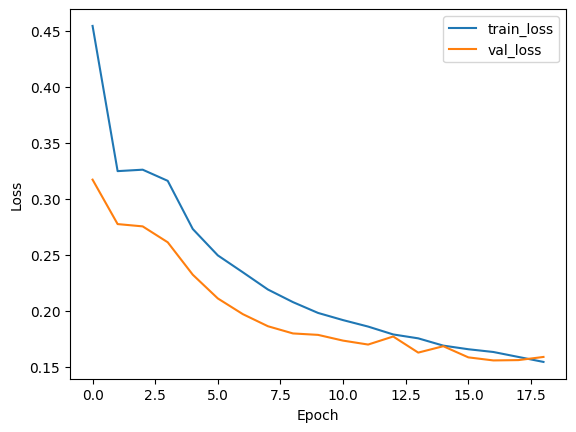

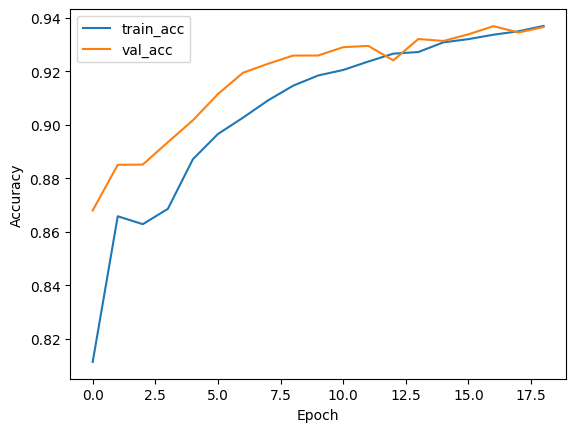

In [22]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [24]:
# Save the full model
model.save('base-glove_BiLSTM.keras')